In [ ]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

In [ ]:
import pandas as pd

# Step 2: Load Dataset
df = pd.read_csv("/content/drive/MyDrive/Car_Dataset/CAR DETAILS FROM CAR DEKHO.csv")


print(df.head())


                       name  year  selling_price  km_driven    fuel  \
0             Maruti 800 AC  2007          60000      70000  Petrol   
1  Maruti Wagon R LXI Minor  2007         135000      50000  Petrol   
2      Hyundai Verna 1.6 SX  2012         600000     100000  Diesel   
3    Datsun RediGO T Option  2017         250000      46000  Petrol   
4     Honda Amaze VX i-DTEC  2014         450000     141000  Diesel   

  seller_type transmission         owner  
0  Individual       Manual   First Owner  
1  Individual       Manual   First Owner  
2  Individual       Manual   First Owner  
3  Individual       Manual   First Owner  
4  Individual       Manual  Second Owner  


In [ ]:

# Step 3: Check for missing values
print(df.isnull().sum())


name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


In [ ]:
df.drop(['name'], axis=1, inplace=True)


In [ ]:
# Encode categorical columns
le = LabelEncoder()
df['fuel'] = le.fit_transform(df['fuel'])                  # e.g., Petrol=2, Diesel=0, CNG=1
df['seller_type'] = le.fit_transform(df['seller_type'])    # Dealer=0, Individual=1
df['transmission'] = le.fit_transform(df['transmission'])  # Manual=1, Automatic=0
df['owner'] = le.fit_transform(df['owner'])                # First Owner=1, Second Owner=2, etc.


In [ ]:
# Step 6: Define Features and Target
X = df.drop(['selling_price'], axis=1)
y = df['selling_price']

In [ ]:

# Step 7: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)



In [ ]:
# Decision Tree
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)


In [ ]:
# Random Forest
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [ ]:
# XGBoost
xgb_model = xgb.XGBRegressor()
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
# Step 9: Evaluation Function
def evaluate(y_true, y_pred, model_name):
    print(f"\n--- {model_name} ---")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R² Score:", r2_score(y_true, y_pred))

In [ ]:

# Step 10: Evaluate All Models
evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_dt, "Decision Tree")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_xgb, "XGBoost")


--- Linear Regression ---
MAE: 222188.9426151671
RMSE: 430073.77286430175
R² Score: 0.3939008529340018

--- Decision Tree ---
MAE: 179995.1654929396
RMSE: 439459.79932119936
R² Score: 0.3671568824825914

--- Random Forest ---
MAE: 168342.59439079135
RMSE: 390872.38066586456
R² Score: 0.4993574901159641

--- XGBoost ---
MAE: 170009.84375
RMSE: 402971.9532870743
R² Score: 0.4678826332092285


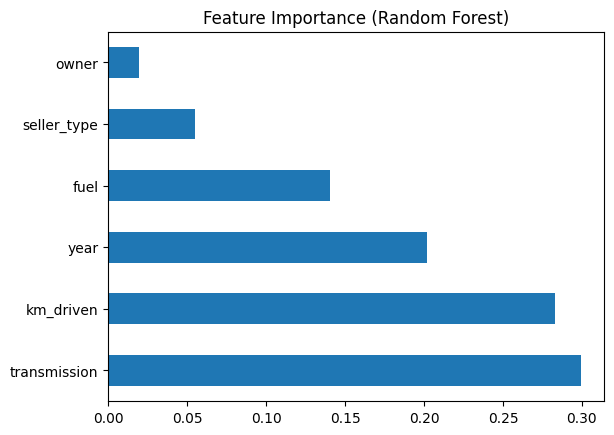

In [ ]:
# Step 11: Feature Importance (Random Forest)
feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.nlargest(7).plot(kind='barh')
plt.title("Feature Importance (Random Forest)")
plt.show()


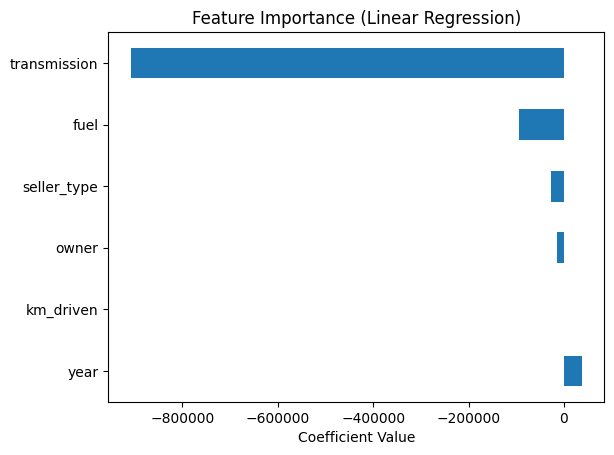

In [ ]:
# Step 11a: Feature Importance (Linear Regression)
coeff_importances = pd.Series(lr.coef_, index=X.columns)
coeff_importances.nlargest(7).plot(kind='barh')
plt.title("Feature Importance (Linear Regression)")
plt.xlabel("Coefficient Value")
plt.show()


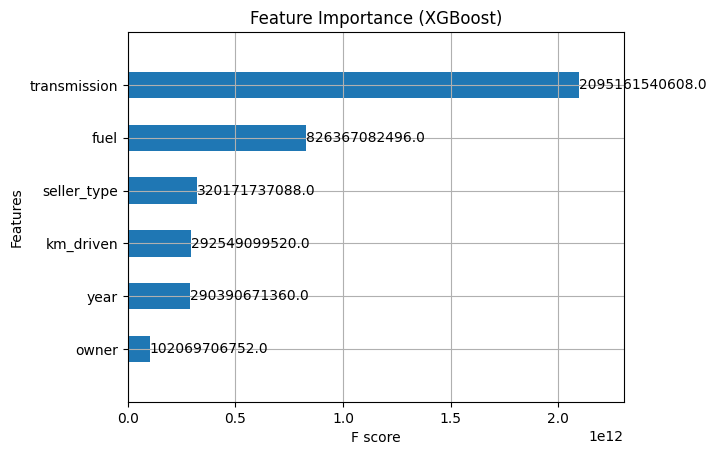

In [ ]:
# Step 11b: Feature Importance (XGBoost)
xgb.plot_importance(xgb_model, max_num_features=7, height=0.5, importance_type='gain')
plt.title("Feature Importance (XGBoost)")
plt.show()


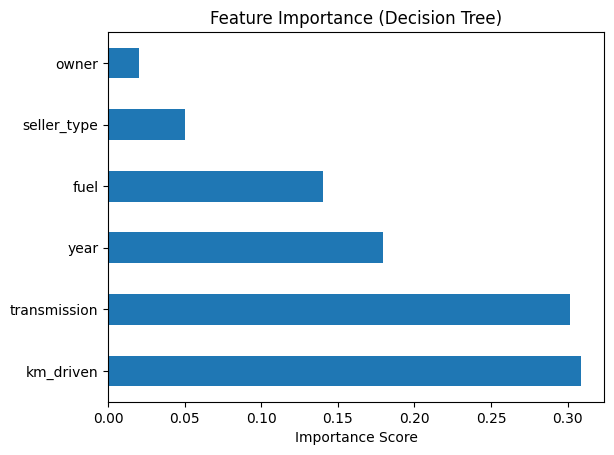

In [ ]:
# Step 11d: Feature Importance (Decision Tree)
dt_feat_importances = pd.Series(dt.feature_importances_, index=X.columns)
dt_feat_importances.nlargest(7).plot(kind='barh')
plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance Score")
plt.show()


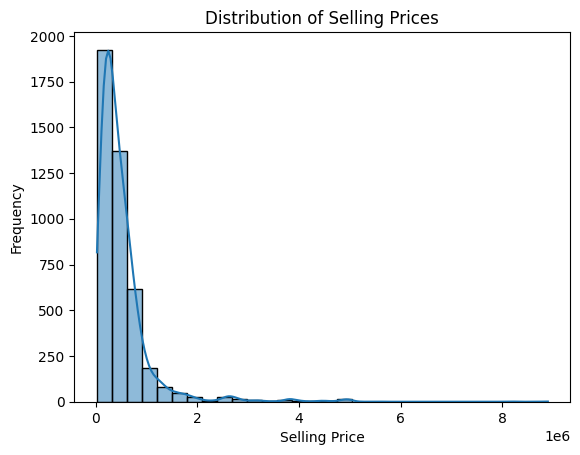

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['selling_price'], kde=True, bins=30)
plt.title('Distribution of Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.show()


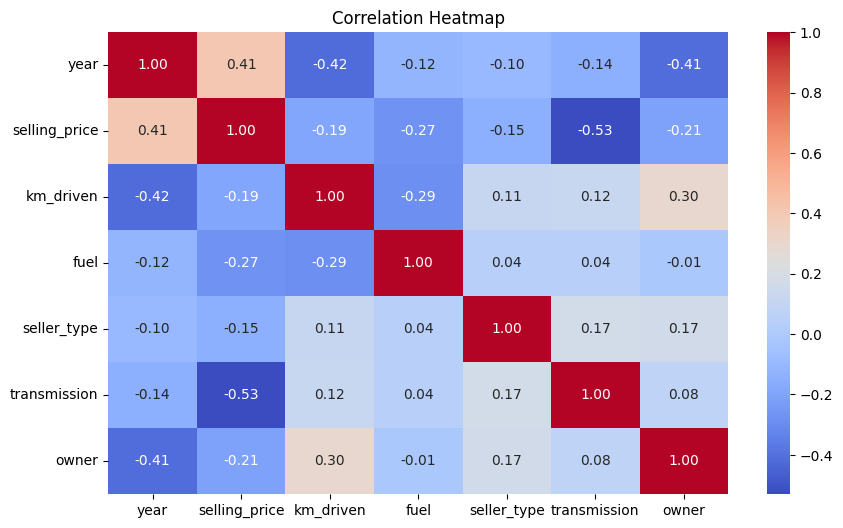

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


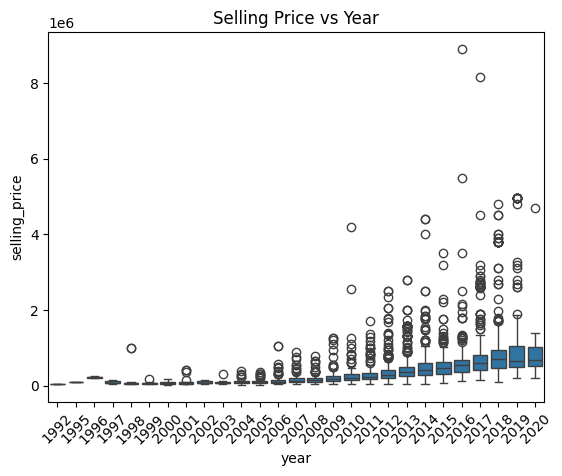

In [ ]:
sns.boxplot(x='year', y='selling_price', data=df)
plt.title('Selling Price vs Year')
plt.xticks(rotation=45)
plt.show()


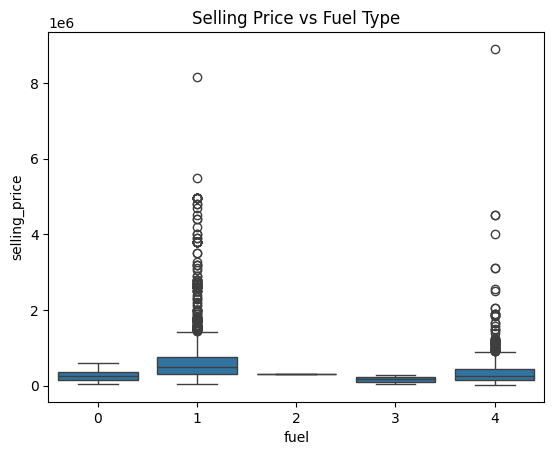

In [ ]:
sns.boxplot(x='fuel', y='selling_price', data=df)
plt.title('Selling Price vs Fuel Type')
plt.show()
